In [8]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# STEP 2: LOAD DATA

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment Data:\n", sentiment.head())
print("Trades Data:\n", trades.head())


Sentiment Data:
     timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
Trades Data:
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   

In [10]:
# STEP 3: BASIC INFO

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing Values:\n", trades.isnull().sum())
print("\nDuplicate Rows:", trades.duplicated().sum())


Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows: 0


In [11]:
# STEP 4: DATA CLEANING

sentiment['Date'] = pd.to_datetime(sentiment['date']).dt.date
trades['Date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True).dt.date

In [12]:
# STEP 5: MERGE DATA


data = pd.merge(trades, sentiment, on='Date', how='inner')

print("Merged Data:\n", data.head())

Merged Data:
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  52

In [13]:
# STEP 6: FEATURE ENGINEERING

data['win'] = data['Closed PnL'] > 0


PnL by Sentiment:
 classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


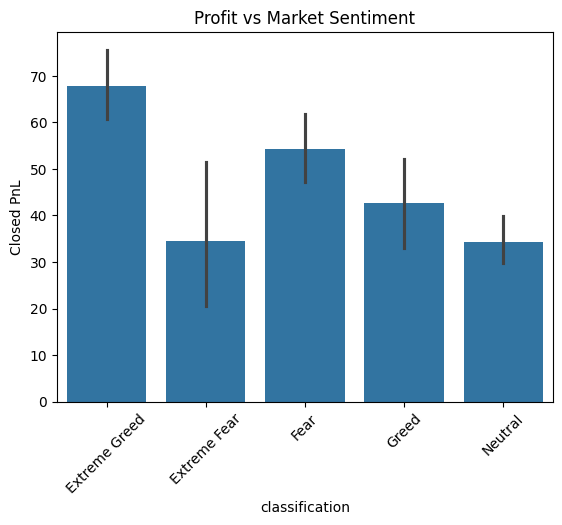


Trade Count:
 classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

Leverage (using Size USD as proxy):
 classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

Long/Short:
 Side
SELL    108528
BUY     102690
Name: count, dtype: int64


In [15]:
# STEP 7: ANALYSIS


# 1. Profit vs Sentiment
pnl = data.groupby('classification')['Closed PnL'].mean()
print("\nPnL by Sentiment:\n", pnl)

sns.barplot(x='classification', y='Closed PnL', data=data)
plt.title("Profit vs Market Sentiment")
plt.xticks(rotation=45)
plt.show()

# 2. Trade Count
trade_count = data.groupby('classification').size()
print("\nTrade Count:\n", trade_count)

# 3. Leverage

leverage = data.groupby('classification')['Size USD'].mean()
print("\nLeverage (using Size USD as proxy):\n", leverage)

# 4. Long/Short
print("\nLong/Short:\n", data['Side'].value_counts())

In [ ]:
# STEP 8: SEGMENTATION

data['lev_group'] = data['Size USD'].apply(lambda x: 'High' if x > data['Size USD'].median() else 'Low')

seg = data.groupby('lev_group')['Closed PnL'].mean()
print("\nSegment Analysis (using Size USD for leverage groups):\n", seg)